## Linear model: FOGD and NZK ZOGD

## Hyperparameters

Values are set in the next code cell.


In [1]:
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
import numpy as np

import copy, os, time
from scipy.io import loadmat, savemat

# RNG seed
torch.manual_seed(0)

degree = 2
sample_num = 100

eta_fo = 1e-3  # FOGD step size
eta_zo = 1e-3  # ZOGD step size
theta_init = torch.normal(mean=0, std=1, size=(degree, 1)) 

In [2]:
output_folder = os.path.join('output_linear_zo_fo_ntk', 'degree_{}'.format(degree))
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [3]:
def target_linear_function(x: torch.tensor, weight: torch.tensor, noise_value, noise = False):
    # sample gaussian noise
    if noise:
        return x @ weight + noise_value
    else:
        return x @ weight

In [4]:
noise_value = torch.normal(mean=0, std=1, size=(sample_num, 1)) / 20.0 # noise value for gt function

theta_gt = torch.randint(1, 10, (degree, 1), dtype=torch.float32)


# initialize several Data Points between [1, 10]
# sample x from a sphere
data_sample = torch.rand(size=(sample_num, degree))
data_sample = data_sample / data_sample.norm(dim=1, keepdim=True, p=2)
target_gt = target_linear_function(data_sample, theta_gt, noise_value, noise=True)

In [5]:
iteration_total = 16000
function_record_iteration_list = [0, 49, 99, 199, 999, 1999, 2999, 3999, iteration_total-1]

## FOGD

In [6]:
fo_theta = copy.deepcopy(theta_init)

f_0 = data_sample @ fo_theta

NTK_kernal_fo = data_sample @ data_sample.t()

f_fo_list = torch.Tensor([])

loss_list_fo = torch.tensor([])
f_diff_list_fo = torch.tensor([])
for i in range(iteration_total):
    loss_0 = 1/2 * (f_0 - target_gt).pow(2).mean()
    loss_list_fo = torch.cat((loss_list_fo, loss_0.view(1)))

    f_1 = f_0 - eta_fo / sample_num *  NTK_kernal_fo.T @ (f_0 - target_gt)
    
    f_diff = f_1 - f_0
    
    if i in function_record_iteration_list:
        f_fo_list = torch.cat((f_fo_list, f_0.unsqueeze(0)))
    
    f_0 = f_1
    f_diff_list_fo = torch.cat((f_diff_list_fo, f_diff.view(1, -1)))
    

    

## NZK ZOGD

In [ ]:
NZK_list_sample = torch.tensor([]).cuda()
data_sample = data_sample.cuda()

for i in range(10000):
    z = torch.normal(0.0, 1.0, size=(1, degree)).cuda()
    z = z.repeat(sample_num, 1)
    
    first_term = z @ data_sample.T
    second_term = z @ data_sample.T
    third_term = z @ z.T
    
    NZK_temp = first_term.T * second_term * third_term

    NZK_list_sample = torch.cat((NZK_list_sample, NZK_temp.unsqueeze(0)))

NZK_kernal_zo = NZK_list_sample.mean(dim=0).cpu()
data_sample = data_sample.cpu()

In [8]:
zo_theta = copy.deepcopy(theta_init)

f_0 = data_sample @ zo_theta
f_diff_list_zo = torch.tensor([])
loss_list_zo = torch.tensor([])

f_zo_list = torch.Tensor([])

for i in range(iteration_total):
    loss_0 = 1/2 * (f_0 - target_gt).pow(2).mean()
    loss_list_zo = torch.cat((loss_list_zo, loss_0.view(1)))
    
    f_1 = f_0 - eta_zo / sample_num * NZK_kernal_zo.T @ (f_0 - target_gt)
    
    f_diff = f_1 - f_0
    
    if i in function_record_iteration_list:
        f_zo_list = torch.cat((f_zo_list, f_0.unsqueeze(0)))
    
    f_0 = f_1
    f_diff_list_zo = torch.cat((f_diff_list_zo, f_diff.view(1, -1)))



In [9]:
# --------------------- save all data ---------------------
savemat(os.path.join(output_folder, 'data.mat'), {
    'theta_gt': theta_gt.numpy(),
    'data_sample': data_sample.numpy(),
    'target_gt': target_gt.numpy(),
    'noise_value': noise_value.numpy(),
    'f_fo_list': f_fo_list.numpy(),
    'f_zo_list': f_zo_list.numpy(),
    'loss_list_fo': loss_list_fo.numpy(),
    'loss_list_zo': loss_list_zo.numpy(),
    'f_diff_list_fo': f_diff_list_fo.numpy(),
    'f_diff_list_zo': f_diff_list_zo.numpy(),
    'function_record_iteration_list': function_record_iteration_list,
    'NTK_kernal_fo': NTK_kernal_fo.numpy(),
    'NZK_kernal_zo': NZK_kernal_zo.numpy()
})

## Plots (2D)

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from matplotlib import cm
from mpl_toolkits.mplot3d.axes3d import get_test_data
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Loss

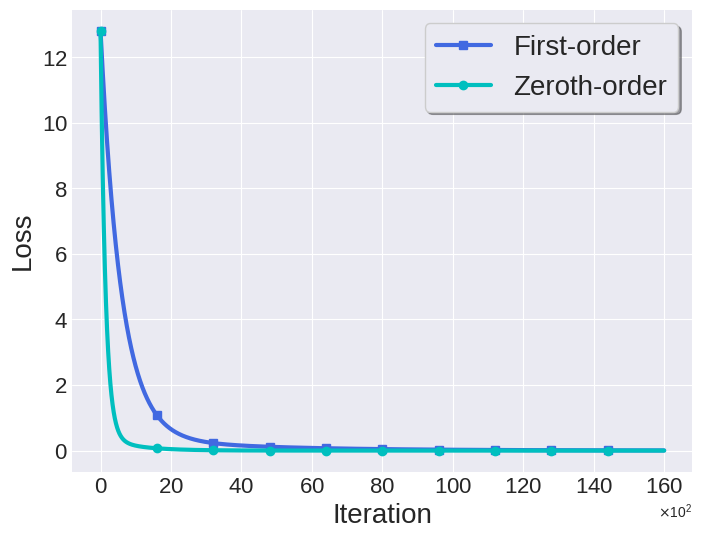

In [15]:
# plot the loss_list_fo and loss_list_zo
plt.style.use('seaborn-v0_8-darkgrid')

sf = plt.figure(figsize=(8,6), dpi=100)
ax = sf.add_subplot()
plt.plot(loss_list_fo[:].detach().numpy(),color='royalblue',label='First-order', linewidth=3,  marker='s', markevery=1600)
plt.plot(loss_list_zo[:].detach().numpy(),color='c',label='Zeroth-order', linewidth=3,  marker='o', markevery=1600)

plt.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=16)
plt.ticklabel_format(style='sci', scilimits=(0,2), axis='y',useMathText=True)
plt.ticklabel_format(style='sci', scilimits=(2,2), axis='x',useMathText=True)
plt.legend(fancybox=True, shadow=True,fontsize=20, frameon=True)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.show()

sf.savefig(os.path.join(output_folder,'loss.pdf'), bbox_inches='tight')

## Final fit along $x_1$

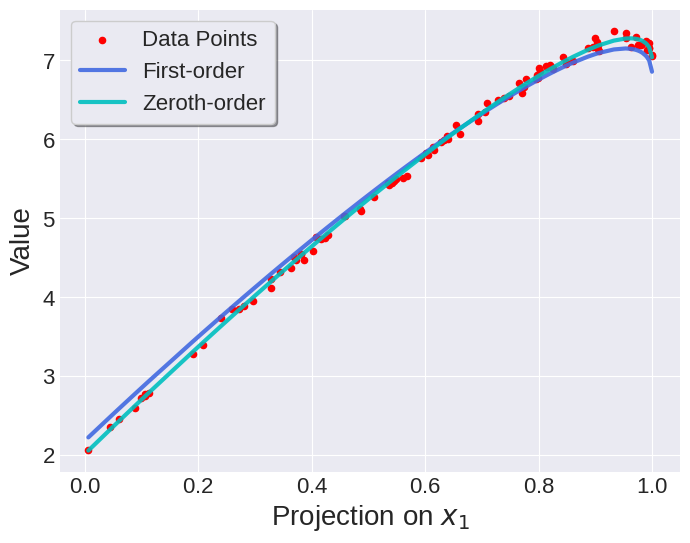

In [ ]:
sf = plt.figure(figsize=(8,6), dpi=100)
ax = sf.add_subplot()

sort_idx = data_sample[:, 0].sort()[1]
sort_data_sample = data_sample[sort_idx]
sort_target_gt = target_gt[sort_idx]
sort_f_fo_list = f_fo_list[-1][sort_idx]
sort_f_zo_list = f_zo_list[-1][sort_idx]


plt.scatter(sort_data_sample[:, 0].detach().numpy(), sort_target_gt.detach().numpy(), color='r', label='Data Points', s= 20)
# plot function learned by first order method
plt.plot(sort_data_sample[:, 0].detach().numpy(), sort_f_fo_list.detach().numpy(), 'royalblue', label='First-order', alpha=0.9, linewidth=3)
# ZO prediction
plt.plot(sort_data_sample[:, 0].detach().numpy(), sort_f_zo_list.detach().numpy(), 'c', label='Zeroth-order', alpha=0.9, linewidth=3)
plt.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=16)
plt.ticklabel_format(style='sci', scilimits=(-3,-2), axis='y',useMathText=True)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x',useMathText=True)
plt.legend(fancybox=True, shadow=True, fontsize=16, frameon=True)
plt.xlabel(r'Projection on $x_1$', fontsize=20)
plt.ylabel('Value', fontsize=20)
plt.show()

sf.savefig(os.path.join(output_folder,'final_optimization.pdf'), bbox_inches='tight')

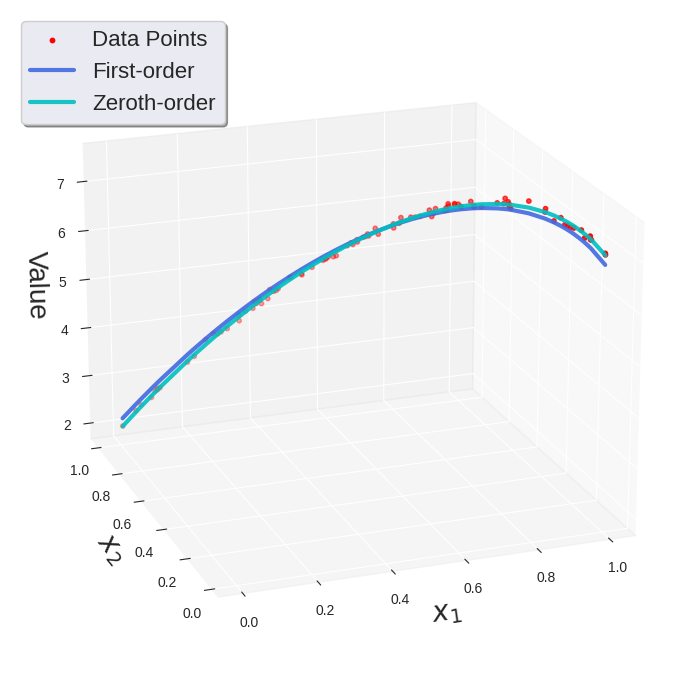

In [ ]:
# plot the target function as a str
fig = plt.figure(figsize=(7,7))
f3d = fig.add_subplot(111, projection='3d')

# set background color as white
f3d.set_facecolor('white')

sort_idx = data_sample[:, 0].sort().indices
sort_data_sample = data_sample[sort_idx]
sort_target_gt = target_gt[sort_idx]
sort_f_fo_list = f_fo_list[-1][sort_idx]
sort_f_zo_list = f_zo_list[-1][sort_idx]


f3d.scatter(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_target_gt.detach().numpy(), color='r', label='Data Points', s = 10)
f3d.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_fo_list.squeeze().detach().numpy(), 'royalblue', label='First-order', linewidth=3, alpha=0.9)
f3d.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_zo_list.squeeze().detach().numpy(), 'c', label='Zeroth-order', linewidth=3, alpha=0.9)
f3d.set_xlabel(r'$x_1$', fontsize=20)
f3d.set_ylabel(r'$x_2$', fontsize=20)
f3d.set_zlabel('Value', fontsize=20)

f3d.legend(fancybox=True, shadow=True, fontsize=16, frameon=True, loc = 'upper left')


azim = int(-110)
dist = int(10)
elev = int(20)
if azim is not None:
    f3d.azim = azim
if dist is not None:
    f3d.dist = dist
if elev is not None:
    f3d.elev = elev
fig.tight_layout()

plt.show()
# save the figure
fig.savefig(os.path.join(output_folder,'final_optimization_3d.pdf'), bbox_inches='tight', pad_inches=0)

## Function evolution

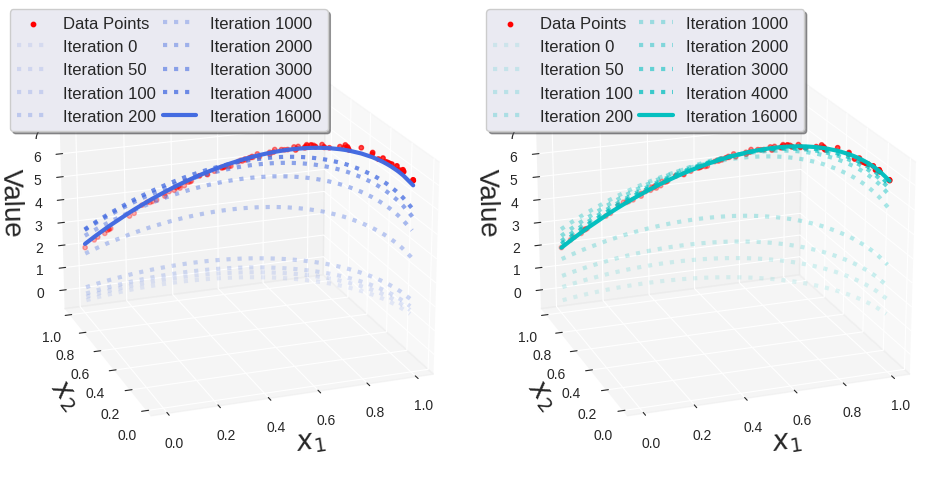

In [ ]:
evolution_vis_style = 2 # do not use style 1 for clear visualization
# ---------------------------------------- style 1 ----------------------------------------
if evolution_vis_style == 1:
    rows = 2
    cols = len(f_zo_list)
    assert len(f_zo_list) == len(f_fo_list) == len(function_record_iteration_list)

    grid = plt.GridSpec(rows, cols, wspace = 0.05, hspace = 0.05)
    fig = plt.figure(figsize=(40,8))

    opacity = 0.1

    for i in range(len(function_record_iteration_list)):
        if i != 9:
            linestyle = 'dotted'
        else:
            linestyle = 'solid'
            
        # plot zo
        ax = fig.add_subplot(grid[0, i]) 
        ax.scatter(data_sample[:, 0].detach().numpy(), target_gt.detach().numpy(), color='r', label='Data Points', s= 20)
        ax.plot(data_sample[:, 0].detach().numpy(), f_zo_list[i].detach().numpy(), 'c', label='Zeroth-order optimization', alpha=opacity, linestyle=linestyle)
        ax.set_title('Iteration {}'.format(function_record_iteration_list[i] + 1 if i != 0 else 0))
        ax.set_xticklabels([])
        if i == 0:
            ax.set_ylabel('Y', fontsize=20)
        else:
            ax.set_yticklabels([])
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in')
        ax.legend(fancybox=True, shadow=True,fontsize="10")
        
        # plot fo
        ax = fig.add_subplot(grid[1, i])
        ax.scatter(data_sample[:, 0].detach().numpy(), target_gt.detach().numpy(), color='r', label='Data Points', s= 20)
        ax.plot(data_sample[:, 0].detach().numpy(), f_fo_list[i].detach().numpy(), 'royalblue', label='First-Order optimization', alpha=opacity, linestyle=linestyle)
        
        ax.set_xlabel('X', fontsize=20)
        if i == 0:
            ax.set_ylabel('Y', fontsize=20)
        else:
            ax.set_yticklabels([])
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in')
        ax.legend(fancybox=True, shadow=True,fontsize="10")
        opacity += 0.1

# ---------------------------------------- style 2 ----------------------------------------

else:
    assert len(f_zo_list) == len(f_fo_list) == len(function_record_iteration_list)
        
    sort_idx = data_sample[:, 0].sort().indices
    sort_data_sample = data_sample[sort_idx]
    sort_target_gt = target_gt[sort_idx]


    grid = plt.GridSpec(1, 2, wspace = 0.05, hspace = 0.05)
    fig = plt.figure(figsize=(12,6))
    opacity = 0.12
    
    # set background color as white
    fig.patch.set_facecolor('white')

    # plot zo
    ax = fig.add_subplot(grid[0, 0], projection='3d')
    ax.set_facecolor('white')
    ax.scatter(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_target_gt.detach().numpy(), color='r', label='Data Points', s= 10)

    for i in range(len(function_record_iteration_list)):
        if i != 8:
            linestyle = 'dotted'
        else:
            linestyle = 'solid'

        sort_f_fo_list = f_fo_list[i][sort_idx]
        ax.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_fo_list.squeeze().detach().numpy(), 'royalblue', 
                label=f'Iteration {function_record_iteration_list[i] + 1 if i!=0 else 0}', alpha=opacity, linestyle=linestyle, linewidth=3)
        ax.set_xlabel(r'$x_1$', fontsize=20)
        ax.set_ylabel(r'$x_2$', fontsize=20)
        ax.set_zlabel('Value', fontsize=20)
        
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=10)
        ax.legend(fancybox=True, shadow=True,fontsize=12, loc='upper left', bbox_to_anchor=(0, 1.02, 0.7, -0.0), ncol=2, mode="expand", borderaxespad=0, frameon=True)
        ax.set_facecolor('white')
        opacity *= 1.3
    
    azim = int(-110)
    dist = int(10)
    elev = int(20)
    if azim is not None:
        ax.azim = azim
    if dist is not None:
        ax.dist = dist
    if elev is not None:
        ax.elev = elev

    # plot fo
    opacity = 0.12
    ax = fig.add_subplot(grid[0, 1], projection='3d')
    ax.scatter(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_target_gt.detach().numpy(), color='r', label='Data Points', s=10)
    for i in range(len(function_record_iteration_list)):
        if i != 8:
            linestyle = 'dotted'
        else:
            linestyle = 'solid'
        
        sort_f_zo_list = f_zo_list[i][sort_idx]
        ax.plot(sort_data_sample[:, 0].detach().numpy(), sort_data_sample[:, 1].detach().numpy(), sort_f_zo_list.squeeze().detach().numpy(), 'c', 
                label=f'Iteration {function_record_iteration_list[i] + 1 if i!=0 else 0}', alpha=opacity, linestyle=linestyle, linewidth=3)
        ax.set_xlabel(r'$x_1$', fontsize=20)
        ax.set_ylabel(r'$x_2$', fontsize=20)
        ax.set_zlabel('Value', fontsize=20)
        ax.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=10)
        ax.legend(fancybox=True, shadow=True,fontsize=12, loc='upper left', bbox_to_anchor=(0, 1.02, 0.7, -0.0), ncol=2, mode="expand", borderaxespad=0, frameon=True)
        ax.set_facecolor('white')
        opacity *= 1.3
    
    azim = int(-110)
    dist = int(10)
    elev = int(20)
    if azim is not None:
        ax.azim = azim
    if dist is not None:
        ax.dist = dist
    if elev is not None:
        ax.elev = elev

plt.show()
fig.savefig(os.path.join(output_folder,f'Evolution_process_style{evolution_vis_style}.pdf'), bbox_inches='tight')

## NTK and NZK heatmaps

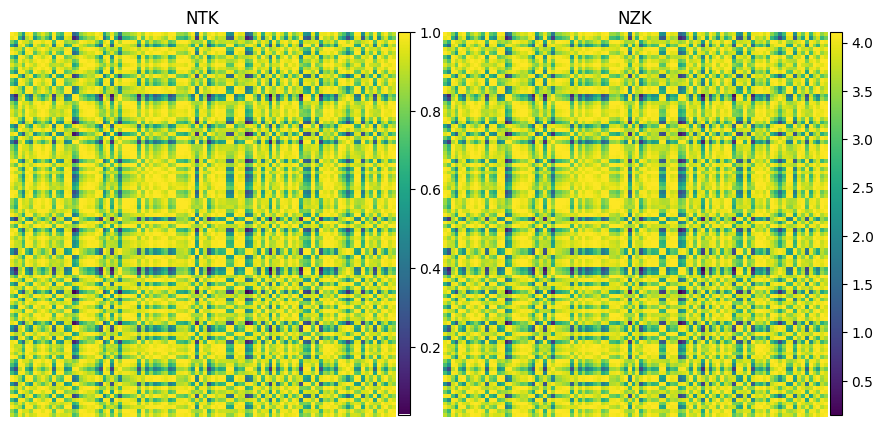

In [ ]:
# return to defualt style
plt.style.use('default')
grid = plt.GridSpec(1, 2, wspace = -0.13, hspace = 0.05)

fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(grid[0, 0])
norm_fo = plt.Normalize(NTK_kernal_fo.min(), NTK_kernal_fo.max())
ax.imshow(NTK_kernal_fo.detach().numpy(), label='NTK')
ax.title.set_text('NTK')
ax.axis('off')

cbar_ax = fig.add_axes([0.495, 0.115, 0.01, 0.765])
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm_fo)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)

ax = fig.add_subplot(grid[0, 1])
norm_zo = plt.Normalize(NZK_kernal_zo.min(), NZK_kernal_zo.max())
ax.imshow(NZK_kernal_zo.detach().numpy(), label='NZK')
ax.title.set_text('NZK')
ax.axis('off')
# add colorbar

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
cbar_ax = fig.add_axes([0.855, 0.115, 0.01, 0.765])
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm_zo)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)
plt.show()
# save the figure
fig.savefig(os.path.join(output_folder,'NTK_NZK.pdf'), bbox_inches='tight')